# Salud mental en el area de la tecnologia

El dataset registra las respuestas a una encuesta sobre actitudes hacia la salud mental y la prevalencia de trastornos mentales entre trabajadores de la insdutria de la tecnologia, Abarca desde las percepciones sobre historial familiar, tratamiento buscado, interferencia de la condicion de trabajo hasta el clima organizacional. Tambien cubre areas, como beneficios, anonimato, facilidad para pedir permiso, consecuencias percibidas de hablar del tema con supervisores o colegas del trabajo.

La encuesta fue publicada por OSMI(Open Sourcing Mental Illness), una organizacion sin fines de lucro dedicada a la salud mental en el area de la tecnologia, como parte de su encuestra anual "Mental Health in Tech Survey". Es una encuesta de autoseleccion, distribuida en linea y difundida principalemente en la comunidad Tech.

La columna `Timestamp` muestra que la mayoria de las respuestas se concentran en un lapso de pocos dias a finales de agosto de 2014, con una cola de respuestas dispersas hasta febrero de 2016, probablemente reflejo de que el enlace a esta encuesta quedo activa mucho tiempo despues de la difusion principal de esta encuesta

Cada fila es la respuesta de una persona de manera individual que trabaja o trabajó en o cerca de la industria tecnologica al momento de responder la encuesta. No es una unica empresa ni un unico pais, fue un encuestado totalmente autoseleccionado.

Al ser una encuesta de autoseleccion sin muestreo probabilistico, cualquier proporcion o distribucion describe a quienes respondieron esta encuesta, no a la industria en general.







## Librerias utilizadas

In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Verificacion de la estructura de datos

In [ ]:
df = pd.read_csv('survey.csv')
if df.shape[0] == 0:
    print('Advertencia: El archivo está vacío.')
n_filas = df.shape[0]
n_columnas = df.shape[1]
print(f'Número de filas: {n_filas}')
print(f'Número de columnas: {n_columnas}')
columnas_esperadas = 27
cumple_columnas = (n_columnas == columnas_esperadas)
print(f'¿Tiene exactamente {columnas_esperadas} columnas?: {cumple_columnas}')
age_es_numerico = pd.api.types.is_integer_dtype(df['Age'])
print(f'¿La columna "Age" es numérica (entero)?: {age_es_numerico}')
timestamp_es_texto = (df['Timestamp'].dtype == object)
print(f'¿La columna "Timestamp" es texto?: {timestamp_es_texto}')
sin_columnas_vacias = (df.isna().mean() < 1.0).all()
print(f'¿El dataset NO tiene columnas completamente vacías?: {sin_columnas_vacias}')

Número de filas: 1259
Número de columnas: 27
¿Tiene exactamente 27 columnas?: True
¿La columna "Age" es numérica (entero)?: True
¿La columna "Timestamp" es texto?: False
¿El dataset NO tiene columnas completamente vacías?: True


El archivo contiene 1259 filas y 27 columnas, las 27 columnas cumplen lo esperado, no hay columnas completamente vacias, y los tipos base son consistentes

## Analisis de la calidad de datos

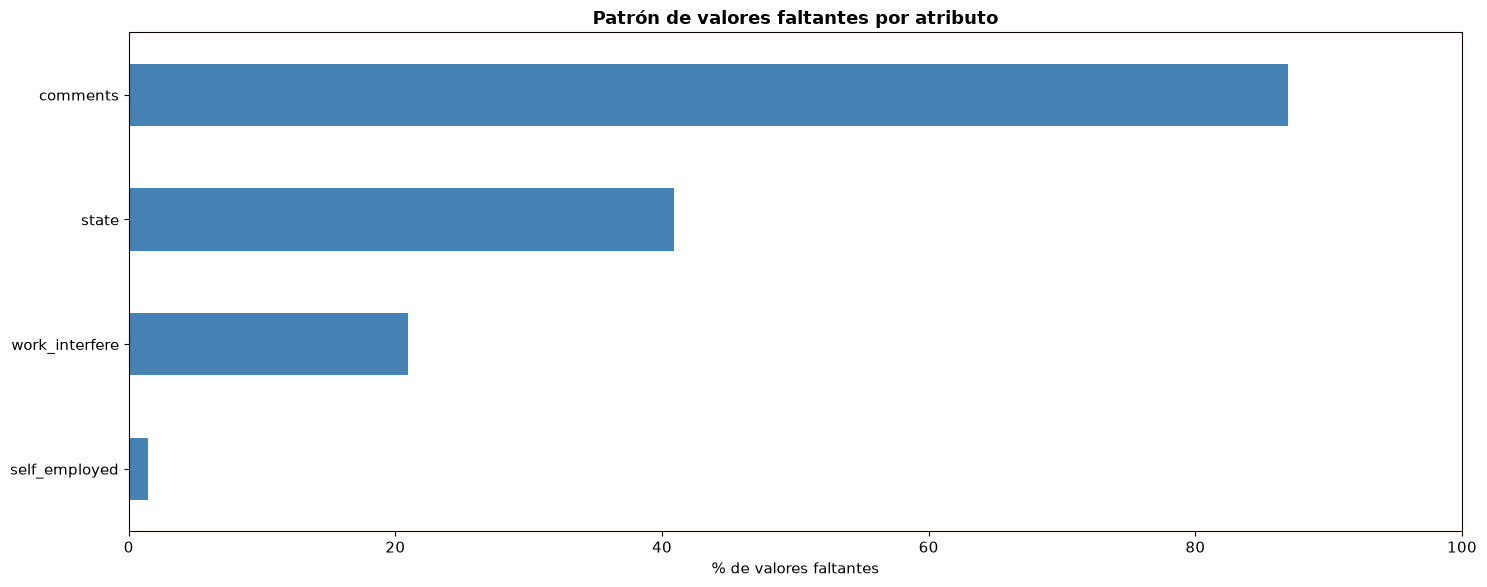

In [34]:

fallo = (df.isna().mean() * 100)
fallo = fallo[fallo > 0].sort_values() 
plt.figure(figsize=(15, 6))
fallo.plot(kind='barh', color='steelblue')
plt.title('Patrón de valores faltantes por atributo')
plt.xlabel('% de valores faltantes')
plt.xlim(0, 100) 
plt.tight_layout()
plt.show()

Figura 1.- Porcentaje de valores faltantes por atributo (solo se muestran los que tienen al menos un dato faltante).

El patron no es aleatorio. `commnents` es el atributo que cuenta con un 87% de datos faltantes de los casos, es un campo opcional en la encuesta, asi que era predecible la ausencia de datos en esta seccion.

# Duplicados

No existen filas completamente duplicadas, si hay 13 pares de filas con el mismo `Timestamp` al segundo exacto, pero al inspeccionarlas tienen edades, generos y paises distintos, son respuestas simultaneas de personas distintas, no duplicados reales. Es una falsa alarma que vale la pena recalcar par que en un analisis a futuro no se eliminen por error.

# Datos imposibles

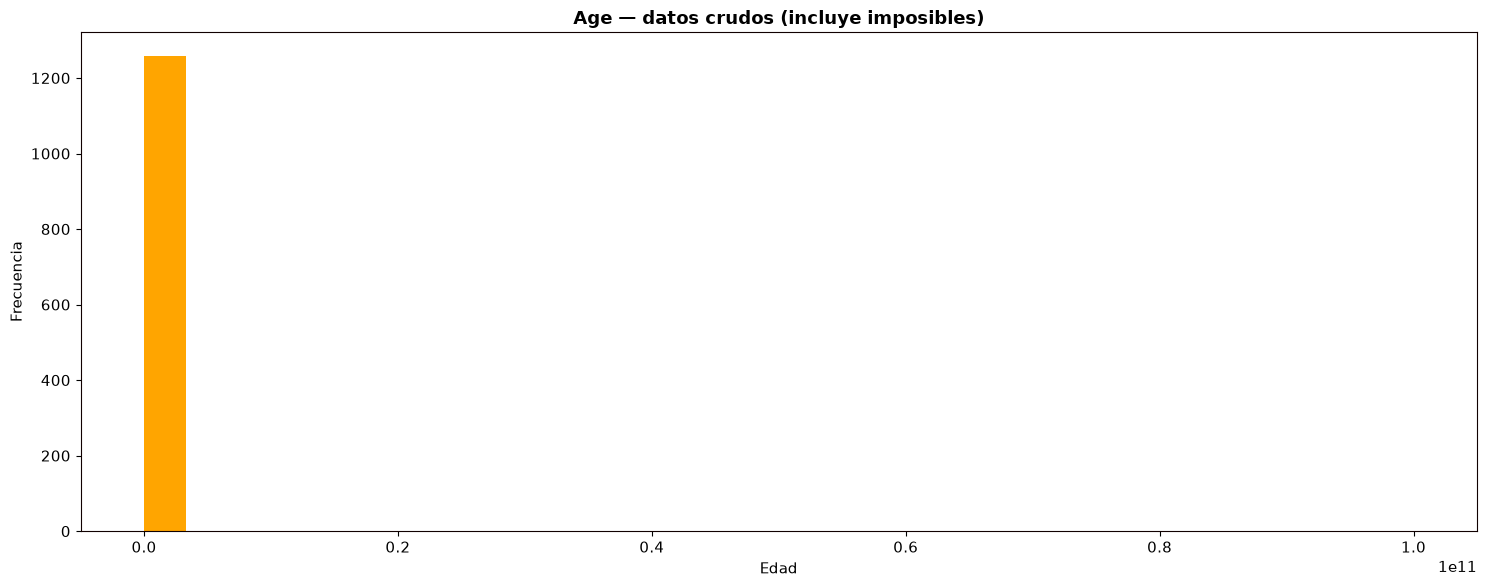

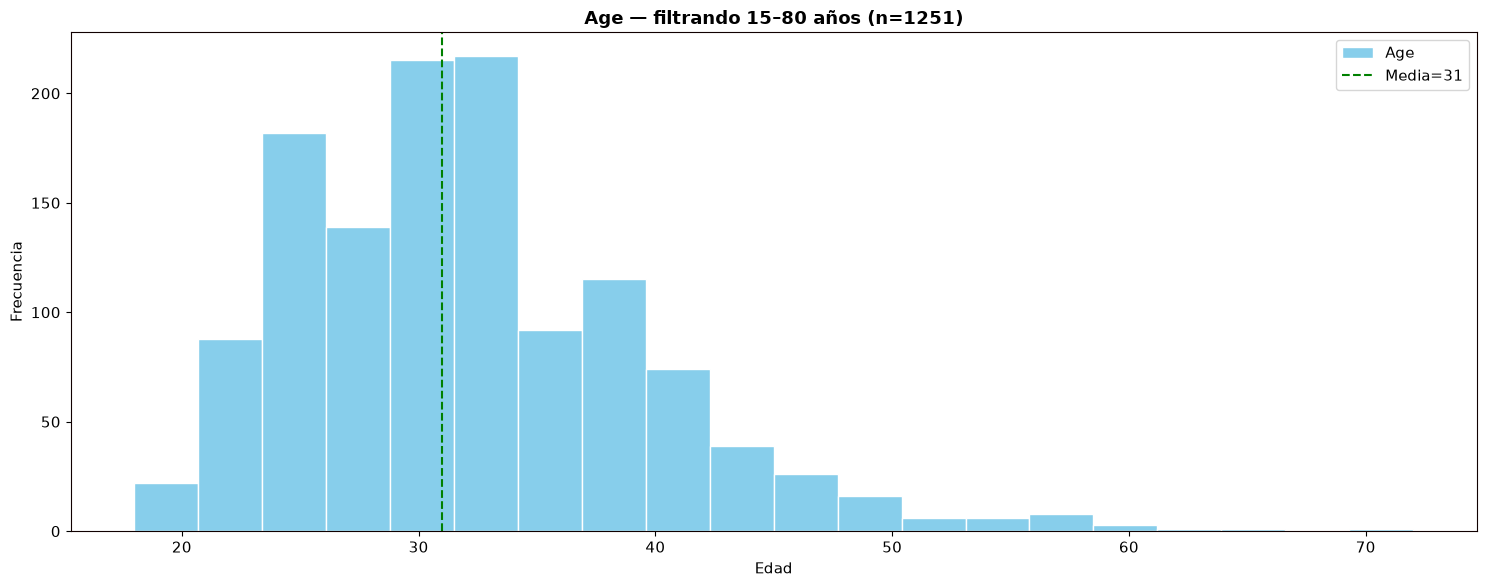

In [ ]:
plt.figure(figsize=(15, 6))
df['Age'].plot(kind='hist', bins=30, color='orange')
plt.title('Age — datos crudos (incluye imposibles)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()
valid = df[(df['Age'] >= 15) & (df['Age'] <= 80)]['Age'].dropna()
media = valid.median()
cantidad = len(valid)
plt.figure(figsize=(15, 6))
valid.plot(kind='hist', bins=20, color='skyblue', edgecolor='white')
plt.axvline(mediana, color='green', linestyle='--', label=f'Media={mediana:.0f}')
plt.title(f'Age — filtrando 15–80 años (n={cantidad})')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

Figura 2.- La primera grafica, muestra una distribucion cruda de la edad, dominada por outliers extremos, en la siguiente grafica, es la grafica filtrando la edad entre 15 y 80 años.

El histograma crudo es practicamente ilegible por que ocho valores rompen la escala, edades de -1726, -29,-1,5,8,11,329 y 99999999999 años. Ninguno es una edad humana realista para esta encuesta, los valores negativos, el valor astronomico y las edades irreales sugieren un error en la captura de datos o puede que se haya tratado de un prueba troll con años que son tecnicamente positivos pero incompatibles con un tranajador de la industria Tech.

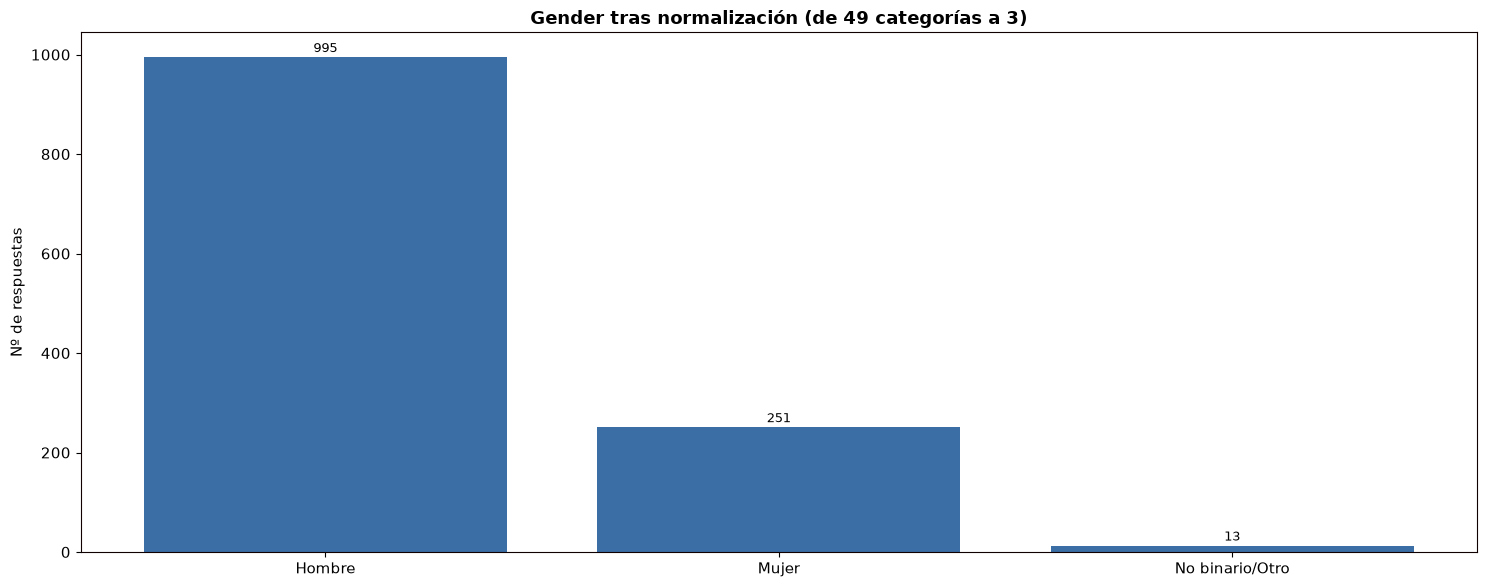

In [56]:
MALE_SET = {
    "male", "m", "man", "cis male", "cis man", "malr", "mal", "maile", "make",
    "msle", "male (cis)", "mail", "male-ish", "guy (-ish) ^_^",
    "something kinda male?", "male leaning androgynous",
    "ostensibly male, unsure what that really means",
}
FEMALE_SET = {
    "female", "f", "woman", "cis female", "femake", "female (cis)",
    "female (trans)", "cis-female/femme", "trans woman", "trans-female",
    "femail",
}

def norm_gender(g):
    if pd.isna(g):
        return "No especifica"
    g = str(g).strip().lower()
    if g in MALE_SET:
        return "Hombre"
    if g in FEMALE_SET:
        return "Mujer"
    return "No binario/Otro"

df["Gender_clean"] = df["Gender"].apply(norm_gender)

fig, ax = plt.subplots(figsize=(15, 6))
gc = df["Gender_clean"].value_counts()
bars = ax.bar(gc.index, gc.values, color=PALETTE[:3])
ax.set_title("Gender tras normalización (de 49 categorías a 3)")
ax.set_ylabel("Nº de respuestas")
for b, v in zip(bars, gc.values):
    ax.text(b.get_x()+b.get_width()/2, v+10, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

Figura 3.- el atributo del genero tiene 49 unicos calores unicos, tras normalizar a 3 categorias equivalentes, la distribucion se puede analizar

El atributo de `Gender` fue un campo de texto libre y produjo 49 tipos de datos distintos para esencialmente 3 categorías. Tras normalizar: 995 Hombres (79%), 251 Mujeres, 13 No binario/otro desbalance fuerte hacia hombres, coherente con la demografía histórica en la industria tech.

# Analisis Univariado

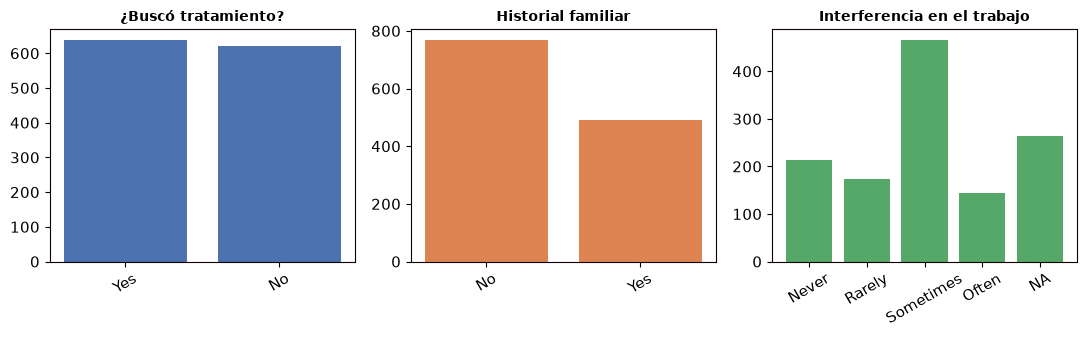

In [ ]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868"]
ORDER_INTERFERE = ["Never", "Rarely", "Sometimes", "Often", "NA"]

cols = ["treatment", "family_history", "work_interfere"]
titles = ["¿Buscó tratamiento?", "Historial familiar", "Interferencia en el trabajo"]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

for ax, col, title, color in zip(axes, cols, titles, PALETTE):
    counts = df[col].fillna("NA").value_counts()
    if col == "work_interfere":
        counts = counts.reindex(ORDER_INTERFERE, fill_value=0)

    ax.bar(counts.index.astype(str), counts.values, color=color)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Fig 4.- Distribucion de las tres variables centrales

EL atributo de `treatment` esta casi perfectamente balanceado (50.7% en si y 49.4% en No) este comparativo es favorable casi para cualquier analisis comparativo posterior, ya que no hay que corregir por clases desbalanceadas. `family_history` muestra que el 39% de los encuestados reporta antencedentes en su familia de enfermedades mentales. En `work_interfere` la categoria modal es "Sometimes" (465 respuestas), y "Often" es la menos comun (144 respuestas) esto nos sugiere que entre quienes tienen algun grado de afectacion, la interferencia severa y constante es relativamente rara frente a la ocasional.

# Analisis bivariado

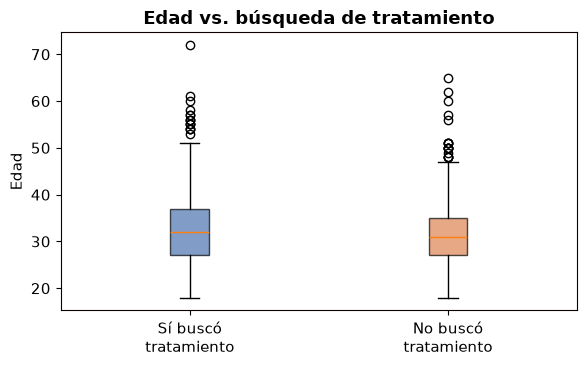

In [68]:
PALETTE = ["#4C72B0", "#DD8452"]
labels = ["Sí buscó\ntratamiento", "No buscó\ntratamiento"]
data = [df.loc[df["treatment"] == t, "Age_valid"].dropna() for t in ["Yes", "No"]]

fig, ax = plt.subplots(figsize=(6, 3.8))
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)

for patch, color in zip(bp["boxes"], PALETTE):
    patch.set(facecolor=color, alpha=0.7)

ax.set(ylabel="Edad", title="Edad vs. búsqueda de tratamiento")
plt.tight_layout()
plt.show()

Fig 5.- Diagrama de caja que muestra la comparacion de edad vs si busco tratamiento

Las dos distribuciones de edad son casi identicas en mediana y rango, la edad, por si sola, apenas discrimina entre quienes buscaron tratamiento y quienes no. Esto es un hallazgo util: descarta a la edad como predictor fuerte y dirige la atencion hacia variables organizacionales, que resultan mas informativas.

# Vista multivariada

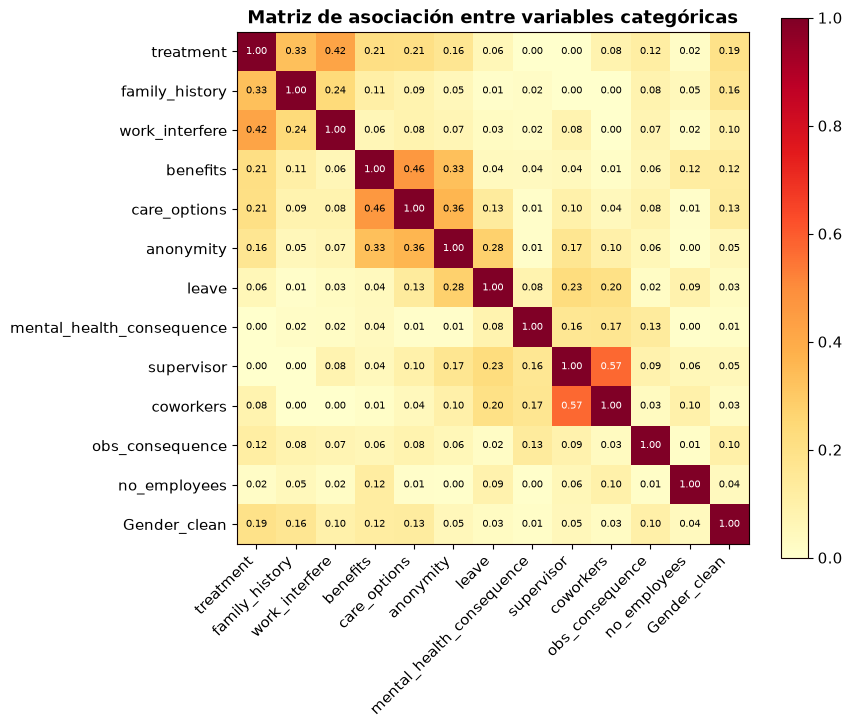

In [95]:
variables = ["treatment", "family_history", "work_interfere", "benefits", "care_options",
             "anonymity", "leave", "mental_health_consequence", "supervisor", "coworkers",
             "obs_consequence", "no_employees", "Gender_clean"]

datos_codificados = pd.DataFrame(index=df.index)
for var in variables:
    datos_codificados[var] = df[var].astype("category").cat.codes

datos_codificados = datos_codificados.replace(-1, np.nan).dropna()
matriz_correlacion = datos_codificados.corr().abs()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(matriz_correlacion, cmap="YlOrRd", vmin=0, vmax=1)

ax.set_xticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=45, ha="right")
ax.set_yticks(range(len(variables)))
ax.set_yticklabels(variables)

for i in range(len(variables)):
    for j in range(len(variables)):
        valor = matriz_correlacion.iloc[i, j]
        color = "white" if valor > 0.5 else "black"
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=7.5, color=color)

ax.set_title("Matriz de asociación entre variables categóricas")
plt.colorbar(im, ax=ax, label="")
plt.tight_layout()
plt.show()

Fig 6.- Esta es una matriz de asociacion entre las 13 variables categoricas clave del cuestionario

El `treatment` se asocia, en orden de fuerza, con la interferencia laboral, historial familiar, opciones de cuidado disponibles y beneficios. En cambio, con supervisor la asociacion es practicamente nula, quien ya busca tratamiento no lo hace mas o menos comodo hablando con el supervisor, lo cual es un hallazgo algo contraintuitivo, uno esperaria que buscar tratamiento y sentirse comodo hablandolo con la jerarquia fueran de la mano. Fuera de la fila de `treatment`, destaca un bloque de asociacion moderada-alta entre anonimato, beneficios y opciones de cuidado, las tres preguntas dependen de que la empresa tenga politica de salud mental formal.

# Conclusion

El dataset como se observo, requiere limpieza no trivial antes de cualquier modelado, la variable de la edad tiene 8 valores fisicamente imposibles y de genero tiene 49 grafias de texto libre para 3 categorias reales, sin este procesamiento, cualquier dato estadistico agregado, queda distorsionado o distorsionado. Hablar del tema con el supervisor, no se asocia con haber buscado tratamiendo, a diferencia de casi todas las demas variables de tema organizacional, sugiere que la comodidad con la jerarquia directa es un fenomeno relativamente independiente del comportamiento de busqueda de ayuda. El organismo organizacional alrededor de la salud mental covaria fuertemente entre si y con el tamaño de empresa, sugiriendo que estas preguntas capturan fondo la madurez instituacional en la salud mental

# Referencias

ifeel. (s.f.). Importancia de la salud mental en el sector tecnológico: un caso de éxito. ifeel. https://ifeelonline.com/es/salud-laboral/salud-mental-sector-tecnologico/

theryo.ai. (s.f.). The mental health crisis in tech that no one admits. theryo.ai. https://theryo.ai/blog/mental-health-crisis-tech-industry/

WebMD Health Services. (s.f.). Workplace mental health statistics by industry. WebMD Health Services. https://www.webmdhealthservices.com/blog/workplace-mental-health-statistics-by-industry/

Mind Share Partners. (2025). 2025 mental health at work report. Mind Share Partners. https://www.mindsharepartners.org/2025-mental-health-at-work-report

Open Sourcing Mental Illness. (2014). Mental Health in Tech Survey [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey